In [23]:
import pandas as pd 
import torch 
from torch import nn 
from sklearn.model_selection import train_test_split 
import matplotlib.pyplot as plt 
from utils import train_and_test_loop, plot_decision_boundary

In [24]:
# Load Dataset
df = pd.read_csv("../dataset/binary_classification_moons.csv")

print(df.head())

         X1        X2  label
0 -0.009332  0.390981      1
1  0.954574 -0.473756      1
2  0.918526 -0.425196      1
3  0.412768 -0.376385      1
4 -0.845320  0.528799      0


In [25]:
# vectorizing X1 and X2 into a single tensor/nparray

X = df[['X1', 'X2']].values
y = df['label'].values

In [26]:
# Turn data into tensors
# Otherwise this causes issues with computations later on
import torch
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, # 20% test, 80% train
                                                    random_state=42) # make the random split reproducible

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [27]:
# Standard PyTorch imports
import torch
from torch import nn

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

device

'cpu'

In [28]:
# Build model with non-linear activation function
from torch import nn
class ModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() # <- add in ReLU activation function
        # Can also put sigmoid in the model 
        # This would mean you don't need to use it on the predictions
        # self.sigmoid = nn.Sigmoid()

    def forward(self, x):
      # Intersperse the ReLU activation function between layers
       return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_2 = ModelV2().to(device)
print(model_2)

ModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


In [29]:
from utils import train_and_test_loop, plot_decision_boundary
import matplotlib.pyplot as plt

Epoch: 0 | Loss: 0.69755, Accuracy: 50.00% | Test loss: 0.69161, Test acc: 50.00%
Epoch: 10 | Loss: 0.64136, Accuracy: 82.38% | Test loss: 0.64063, Test acc: 82.50%
Epoch: 20 | Loss: 0.58804, Accuracy: 84.38% | Test loss: 0.59065, Test acc: 79.50%
Epoch: 30 | Loss: 0.53105, Accuracy: 84.12% | Test loss: 0.53737, Test acc: 79.00%
Epoch: 40 | Loss: 0.47719, Accuracy: 83.88% | Test loss: 0.48693, Test acc: 79.00%
Epoch: 50 | Loss: 0.42965, Accuracy: 84.00% | Test loss: 0.44225, Test acc: 78.50%
Epoch: 60 | Loss: 0.39047, Accuracy: 83.88% | Test loss: 0.40522, Test acc: 79.50%
Epoch: 70 | Loss: 0.36024, Accuracy: 83.75% | Test loss: 0.37625, Test acc: 80.00%
Epoch: 80 | Loss: 0.33781, Accuracy: 84.12% | Test loss: 0.35417, Test acc: 80.50%
Epoch: 90 | Loss: 0.32108, Accuracy: 84.38% | Test loss: 0.33700, Test acc: 81.00%


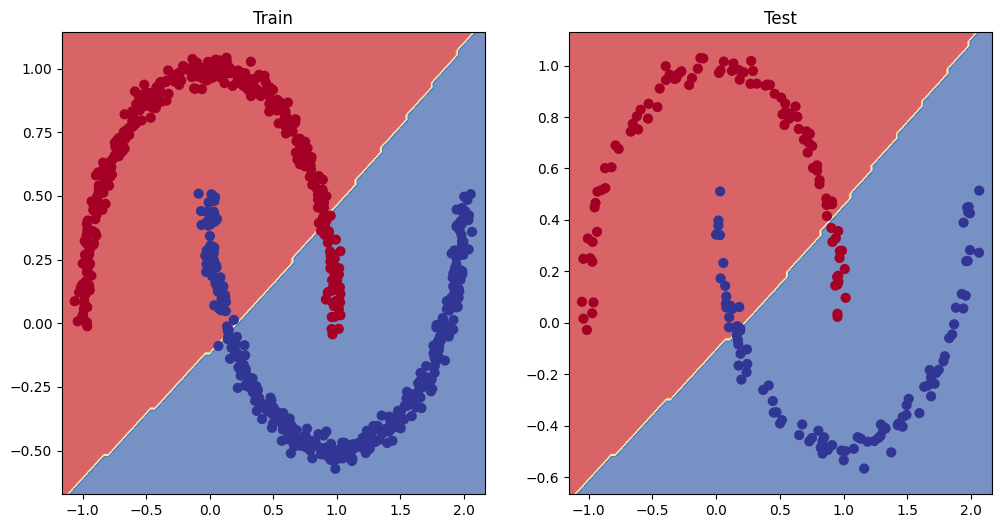

In [30]:
model = model_2
epochs = 100

# Create a loss function
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(), 
                            lr=0.1)

train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)
# plot_loss_curves(train_losses, test_losses)

Epoch: 0 | Loss: 0.66861, Accuracy: 64.38% | Test loss: 0.66280, Test acc: 69.50%
Epoch: 10 | Loss: 0.63108, Accuracy: 78.38% | Test loss: 0.62745, Test acc: 80.50%
Epoch: 20 | Loss: 0.58947, Accuracy: 85.75% | Test loss: 0.58822, Test acc: 83.50%
Epoch: 30 | Loss: 0.53912, Accuracy: 84.88% | Test loss: 0.54059, Test acc: 80.50%
Epoch: 40 | Loss: 0.48283, Accuracy: 84.50% | Test loss: 0.48774, Test acc: 79.50%
Epoch: 50 | Loss: 0.42849, Accuracy: 84.38% | Test loss: 0.43689, Test acc: 80.00%
Epoch: 60 | Loss: 0.38338, Accuracy: 84.50% | Test loss: 0.39427, Test acc: 80.50%
Epoch: 70 | Loss: 0.34976, Accuracy: 85.12% | Test loss: 0.36173, Test acc: 81.00%
Epoch: 80 | Loss: 0.32532, Accuracy: 85.38% | Test loss: 0.33685, Test acc: 83.00%
Epoch: 90 | Loss: 0.30694, Accuracy: 85.88% | Test loss: 0.31726, Test acc: 84.50%
Epoch: 100 | Loss: 0.29258, Accuracy: 86.50% | Test loss: 0.30149, Test acc: 85.00%
Epoch: 110 | Loss: 0.28098, Accuracy: 86.50% | Test loss: 0.28843, Test acc: 85.50%
Epo

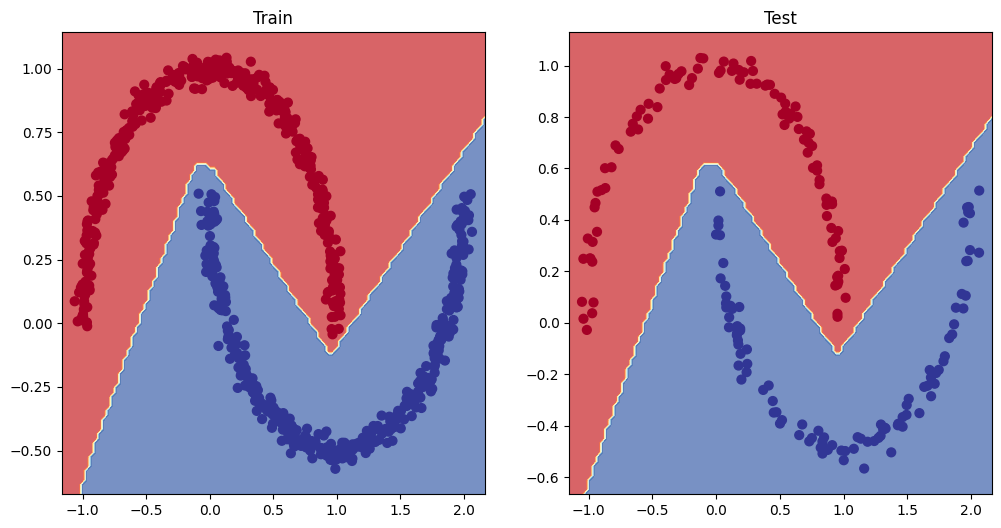

In [31]:
epochs = 1000
model = ModelV2().to(device) # reset model
optimizer = torch.optim.SGD(params=model.parameters(), 
                            lr=0.1)

train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)
# plot_loss_curves(train_losses, test_losses)

Epoch: 0 | Loss: 0.69771, Accuracy: 50.00% | Test loss: 0.69539, Test acc: 50.00%
Epoch: 10 | Loss: 0.67050, Accuracy: 72.25% | Test loss: 0.67049, Test acc: 71.50%
Epoch: 20 | Loss: 0.64386, Accuracy: 84.25% | Test loss: 0.64556, Test acc: 82.50%
Epoch: 30 | Loss: 0.61320, Accuracy: 84.00% | Test loss: 0.61621, Test acc: 84.50%
Epoch: 40 | Loss: 0.57278, Accuracy: 84.00% | Test loss: 0.57712, Test acc: 82.50%
Epoch: 50 | Loss: 0.52065, Accuracy: 85.00% | Test loss: 0.52681, Test acc: 83.50%
Epoch: 60 | Loss: 0.46108, Accuracy: 85.00% | Test loss: 0.46975, Test acc: 84.00%
Epoch: 70 | Loss: 0.40371, Accuracy: 85.25% | Test loss: 0.41475, Test acc: 84.50%
Epoch: 80 | Loss: 0.35693, Accuracy: 85.50% | Test loss: 0.36960, Test acc: 85.00%
Epoch: 90 | Loss: 0.32308, Accuracy: 85.88% | Test loss: 0.33602, Test acc: 86.00%
Epoch: 100 | Loss: 0.30001, Accuracy: 86.38% | Test loss: 0.31187, Test acc: 87.00%
Epoch: 110 | Loss: 0.28359, Accuracy: 87.12% | Test loss: 0.29376, Test acc: 88.00%
Epo

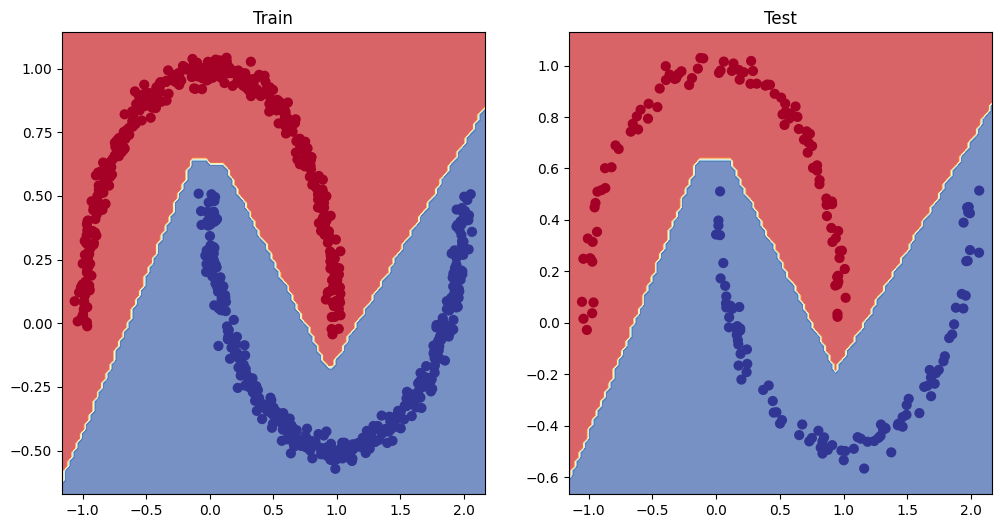

In [32]:
model = ModelV2().to(device) # reset model
epochs = 1500
optimizer = torch.optim.SGD(params=model.parameters(), 
                            lr=0.1)

train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)
# plot_loss_curves(train_losses, test_losses)

## RESULT

#### ModelV0
- Accepts two features.
- Contains only linear transformations.
- Unable to learn nonlinear boundaries.
- Not suitable for the moons dataset.

#### ModelV2
- Uses hidden layers and ReLU activation.
- Learns nonlinear patterns.
- Achieved significantly higher accuracy than random guessing.
- Produced curved decision boundaries matching the moons dataset.


## CONCLUSION
The LinearRegressionNN model is appropriate only for simple linear regression problems. ModelV0 is also unsuitable for the binary_classification_moons dataset because multiple linear layers without activation functions remain equivalent to a single linear model. By introducing ReLU activation functions and additional hidden layers in ModelV2, the network becomes capable of learning nonlinear decision boundaries. Therefore, ModelV2 is the most suitable architecture among the evaluated models for classifying the binary_classification_moons dataset.